In [4]:
import torch
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- CONFIG ---
# Load all normalized features from npz files
cam_npz_dir = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\built_dataset\*_norm.npz"
npz_files = sorted(glob.glob(cam_npz_dir))

# Storage for individual features
degree_list = []
ratio_list = []
speed_list = []
accel_list = []
xyn_list = []
step_list = []

# Storage for combined experimental features
deg_speed_list = []
deg_acc_list = []
deg_ratio_speed_list = []
all_combined_list = []

print(f"Found {len(npz_files)} npz files. Starting extraction...")

for f in npz_files:
    try:
        # Load npz file
        data = np.load(f)

        # 1. Extract base features using keys from your np.savez logic
        # Reshape is used to ensure (T, Dim) structure
        d_feat = data['X_degree']  # [T, pose_dim]
        r_feat = data['X_ratio']   # [T, pose_dim]
        s_feat = data['X_speed']   # [T, pose_dim]
        a_feat = data['X_acc']     # [T, pose_dim]

        x_feat_raw = data['X_xyn']
        x_feat = x_feat_raw.reshape(x_feat_raw.shape[0], -1)
        
        st_feat = data['X_step']   # [T] (Labels)

        # 2. Append to individual lists
        degree_list.append(d_feat)
        ratio_list.append(r_feat)
        speed_list.append(s_feat)
        accel_list.append(a_feat)
        xyn_list.append(x_feat)
        step_list.append(st_feat)

        # 3. Create combinations for ablation studies
        # Combination A: Kinematic focus (Degree + Speed + Accel)
        ds_feat = np.hstack([d_feat, s_feat])
        deg_speed_list.append(ds_feat)
        deg_acc_list.append(np.hstack([d_feat, a_feat]))
        deg_ratio_speed_list.append(np.hstack([d_feat, r_feat, s_feat]))

        # Combination B: All available features (excluding raw step labels)
        combined_feat = np.hstack([d_feat, r_feat, s_feat, a_feat])
        all_combined_list.append(combined_feat)

    except KeyError as e:
        print(f"Key missing in file {f}: {e}")
        continue
    except Exception as e:
        print(f"Error processing {f}: {e}")
        continue

# --- Vertically stack all sequences into single matrices ---
X_deg = np.vstack(degree_list)
X_ratio = np.vstack(ratio_list)
X_speed = np.vstack(speed_list)
X_accel = np.vstack(accel_list)
X_xyn = np.vstack(xyn_list)
X_step = np.concatenate(step_list) # Labels are 1D

X_deg_speed = np.vstack(deg_speed_list)
X_deg_acc = np.vstack(deg_acc_list)
X_deg_ratio_speed = np.vstack(deg_ratio_speed_list)
X_all_combined = np.vstack(all_combined_list)

# --- Standardization (Crucial for KMeans) ---
scaler = StandardScaler()

X_scaled_deg = scaler.fit_transform(X_deg)
X_scaled_ratio = scaler.fit_transform(X_ratio)
X_scaled_speed = scaler.fit_transform(X_speed)
X_scaled_accel = scaler.fit_transform(X_accel)
X_scaled_xyn = scaler.fit_transform(X_xyn)

X_scaled_deg_speed = scaler.fit_transform(X_deg_speed)
X_scaled_deg_accel = scaler.fit_transform(X_deg_acc)
X_scaled_deg_ratio_speed = scaler.fit_transform(X_deg_ratio_speed)
X_scaled_all = scaler.fit_transform(X_all_combined)

# --- Verification ---
print("\n--- Feature Shapes Verified ---")
print(f"Degree Features:      {X_scaled_deg.shape}")
print(f"Speed Features:       {X_scaled_speed.shape}")
print(f"Accel Features:       {X_scaled_accel.shape}")
print(f"Ratio Features:       {X_scaled_ratio.shape}")
print(f"Reshaped XYN Features:     {X_scaled_xyn.shape}")
print(f"Hybrid (Deg+Sp):   {X_scaled_deg_speed.shape}")
print(f"Hybrid (Deg+Ac):      {X_scaled_deg_accel.shape}")  
print(f"Hybrid (Deg+Ratio+Sp): {X_scaled_deg_ratio_speed.shape}")
print(f"All Combined:         {X_scaled_all.shape}")
print(f"Total Labels (Step):  {X_step.shape}")

Found 23 npz files. Starting extraction...

--- Feature Shapes Verified ---
Degree Features:      (61104, 16)
Speed Features:       (61104, 17)
Accel Features:       (61104, 17)
Ratio Features:       (61104, 1)
Reshaped XYN Features:     (61104, 34)
Hybrid (Deg+Sp):   (61104, 33)
Hybrid (Deg+Ac):      (61104, 33)
Hybrid (Deg+Ratio+Sp): (61104, 34)
All Combined:         (61104, 51)
Total Labels (Step):  (61104, 4)


##### add step segmentation info

In [5]:
import json
def overlay_json_markers(ax, video_names, data_path, label_path, target_steps=100):
    """
    Independent helper to draw black lines on an existing heatmap.
    """
    for row_idx, video_base_name in enumerate(video_names):
        json_file = os.path.join(label_path, f"{video_base_name}_steps.json")
        npz_file = os.path.join(data_path, f"{video_base_name}_norm.npz")
        
        if os.path.exists(json_file) and os.path.exists(npz_file):
            # Calculate duration from npz
            data = np.load(npz_file)
            num_frames = data['X_degree'].shape[0]
            fps = float(data['fps']) if 'fps' in data else 30.0
            total_duration = num_frames / fps

            colors = ['black', 'red']  # Extend as needed

            with open(json_file, 'r', encoding='utf-8') as f:
                label_data = json.load(f)
                ind = 0
                for marker in label_data.get('step_markers', []):
                    color = colors[ind % len(colors)]
                    x_pos = (marker['timestamp'] / total_duration) * target_steps
                    # Draw vertical line within the specific row
                    ax.vlines(x=x_pos, ymin=row_idx, ymax=row_idx + 1, 
                              color=color, linewidth=2.5, zorder=5)
                    ind += 1

### Determine which features are more representative and robust

In [6]:
npz_norm_path = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\built_dataset"
json_label_path = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\video_labels"

# Gaussion Mixture Models(GMMs)
### Distribution based

In [7]:
from sklearn.mixture import GaussianMixture

def plot_hybrid_feature_heatmap(X_stacked, data_path,label_path, n_clusters=5, target_steps=100):
    # 1. Get all .npz files
    npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
    if not npz_files:
        print(".npz files not found in the specified directory.")
        return None, None
        
    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))
    # 2. Perform GMM Clustering
    print(f"Performing GMM clustering (K={n_clusters}) on combined features...")
    
    # covariance_type='full' allows each cluster to have its own 3D/nD orientation
    gmm = GaussianMixture(
        n_components=n_clusters, 
        covariance_type='full', 
        random_state=42, 
        reg_covar=1e-6  # Added small value for numerical stability
    )
    
    # Fit the model and predict labels
    global_labels = gmm.fit_predict(X_stacked)

    # 3. Construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 

    for pf in npz_files:
        data = np.load(pf)
        video_name = os.path.basename(pf).replace("_norm.npz", "")
        
        # Determine frame count (using X_degree as reference for T)
        num_frames = data['X_degree'].shape[0]
        
        # Slice the global labels to get this video's specific segment
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        # Temporal alignment (Resampling to 0-100% progress)
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. Plot heatmap
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    # Use tab10 or tab20 depending on the number of clusters
    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20", n_clusters)
    
    ax = sns.heatmap(
        parallel_matrix, 
        cmap=cmap, 
        xticklabels=10, 
        yticklabels=video_names,
        cbar_kws={'label': 'GMM Cluster ID', 'ticks': range(n_clusters)}
    )

    # --- insert labeled markers ---
    if label_path is not None:
        overlay_json_markers(ax, video_names, data_path, label_path, target_steps)
    # -----------------------
    
    plt.title(f"GMM Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    # Set 5% interval ticks for clarity
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

# DBSCAN
### Density based 

In [55]:
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap
#plot_hybrid_feature_heatmap(X_scaled_xyn, npz_norm_path, n_clusters=cluster)
def plot_hybrid_feature_heatmap(X_stacked, data_path, n_clusters):

    eps=0.5
    min_samples=10
    target_steps=100
    # 1. Get all .npz files
    npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
    if not npz_files:
        print(".npz files not found in the specified directory.")
        return None, None
        
    X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

    # 2. Perform DBSCAN Clustering
    print(f"Performing DBSCAN clustering (eps={eps}, min_samples={min_samples})...")
    
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    global_labels = dbscan.fit_predict(X_stacked)

    # Calculate cluster statistics
    unique_labels = np.unique(global_labels)
    n_clusters_found = len([l for l in unique_labels if l >= 0])
    has_noise = -1 in unique_labels
    
    print(f"DBSCAN result: {n_clusters_found} clusters identified.")
    if has_noise:
        print(f"Noise detected (Label -1).")

    # 3. Construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 

    for pf in npz_files:
        data = np.load(pf)
        video_name = os.path.basename(pf).replace("_norm.npz", "")
        
        num_frames = data['X_degree'].shape[0]
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. Prepare Heatmap and Color Mapping
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    # Custom colormap to handle -1 (Noise) as Grey
    base_n = max(1, n_clusters_found)
    base_cmap = plt.get_cmap("tab20", base_n)
    colors = [base_cmap(i) for i in range(base_n)]
    
    if has_noise:
        # Insert grey at the start for noise (-1)
        colors.insert(0, (0.5, 0.5, 0.5, 1.0)) 
        # Shift labels by +1 so that -1 becomes index 0 for the colormap
        plot_matrix = parallel_matrix + 1
        cbar_ticks = np.arange(n_clusters_found + 1)
        cbar_labels = ['Noise (-1)'] + [f'Cluster {i}' for i in range(n_clusters_found)]
    else:
        plot_matrix = parallel_matrix
        cbar_ticks = np.arange(n_clusters_found)
        cbar_labels = [f'Cluster {i}' for i in range(n_clusters_found)]

    my_cmap = ListedColormap(colors)

    # 5. Plot heatmap
    sns.heatmap(
        plot_matrix, 
        cmap=my_cmap, 
        xticklabels=10, 
        yticklabels=video_names,
        cbar_kws={'label': 'Cluster Analysis', 'ticks': cbar_ticks}
    )
    
    # Update colorbar tick labels
    colorbar = plt.gca().collections[0].colorbar
    colorbar.set_ticklabels(cbar_labels)

    plt.title(f"DBSCAN Hybrid Feature Pattern Analysis (eps={eps})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return dbscan, parallel_matrix

# KMeans
### Centroid based

In [77]:
def plot_hybrid_feature_heatmap(X_stacked, data_path, json_label_path, n_clusters=5, target_steps=100):
    # get all .npz files
    npz_files = sorted(glob.glob(os.path.join(data_path, "*_norm.npz")))
    if not npz_files:
        print(".npz files not found in the specified directory.")
        return

    # 2. global K-Means clustering on the stacked features
    print("Performing K-Means clustering on combined features...")
    
    # use different clustering methods here if needed(gaussion mixture, hierarchical clustering, etc.)
    # KMEANS
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    global_labels = kmeans.fit_predict(X_stacked)

    # 


    # 3. construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 #

    for pf in npz_files:
        data = np.load(pf)
        video_name = os.path.basename(pf).replace("_norm.npz", "")
        
        # get number of frames for this video
        num_frames = data['X_degree'].shape[0]
        
        # extract corresponding cluster labels for this video's frames
        video_labels = global_labels[current_ptr : current_ptr + num_frames]

        current_ptr += num_frames
        
        # align (Resampling to 0-100%)
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. plot heatmap
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    cmap = plt.get_cmap("tab20", n_clusters)
    ax = sns.heatmap(parallel_matrix, 
                cmap=cmap, 
                xticklabels=10, 
                yticklabels=video_names,
                cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)})
                
    # --- insert labeled markers ---
    if json_label_path is not None:
        overlay_json_markers(ax, video_names, data_path, json_label_path, target_steps)
    # -----------------------

    plt.title(f"Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    # 5% interval ticks
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return ax, parallel_matrix

In [8]:
cluster = 5

# Individual Features


--- Analyzing Reshaped XYN Features ---
Performing GMM clustering (K=5) on combined features...


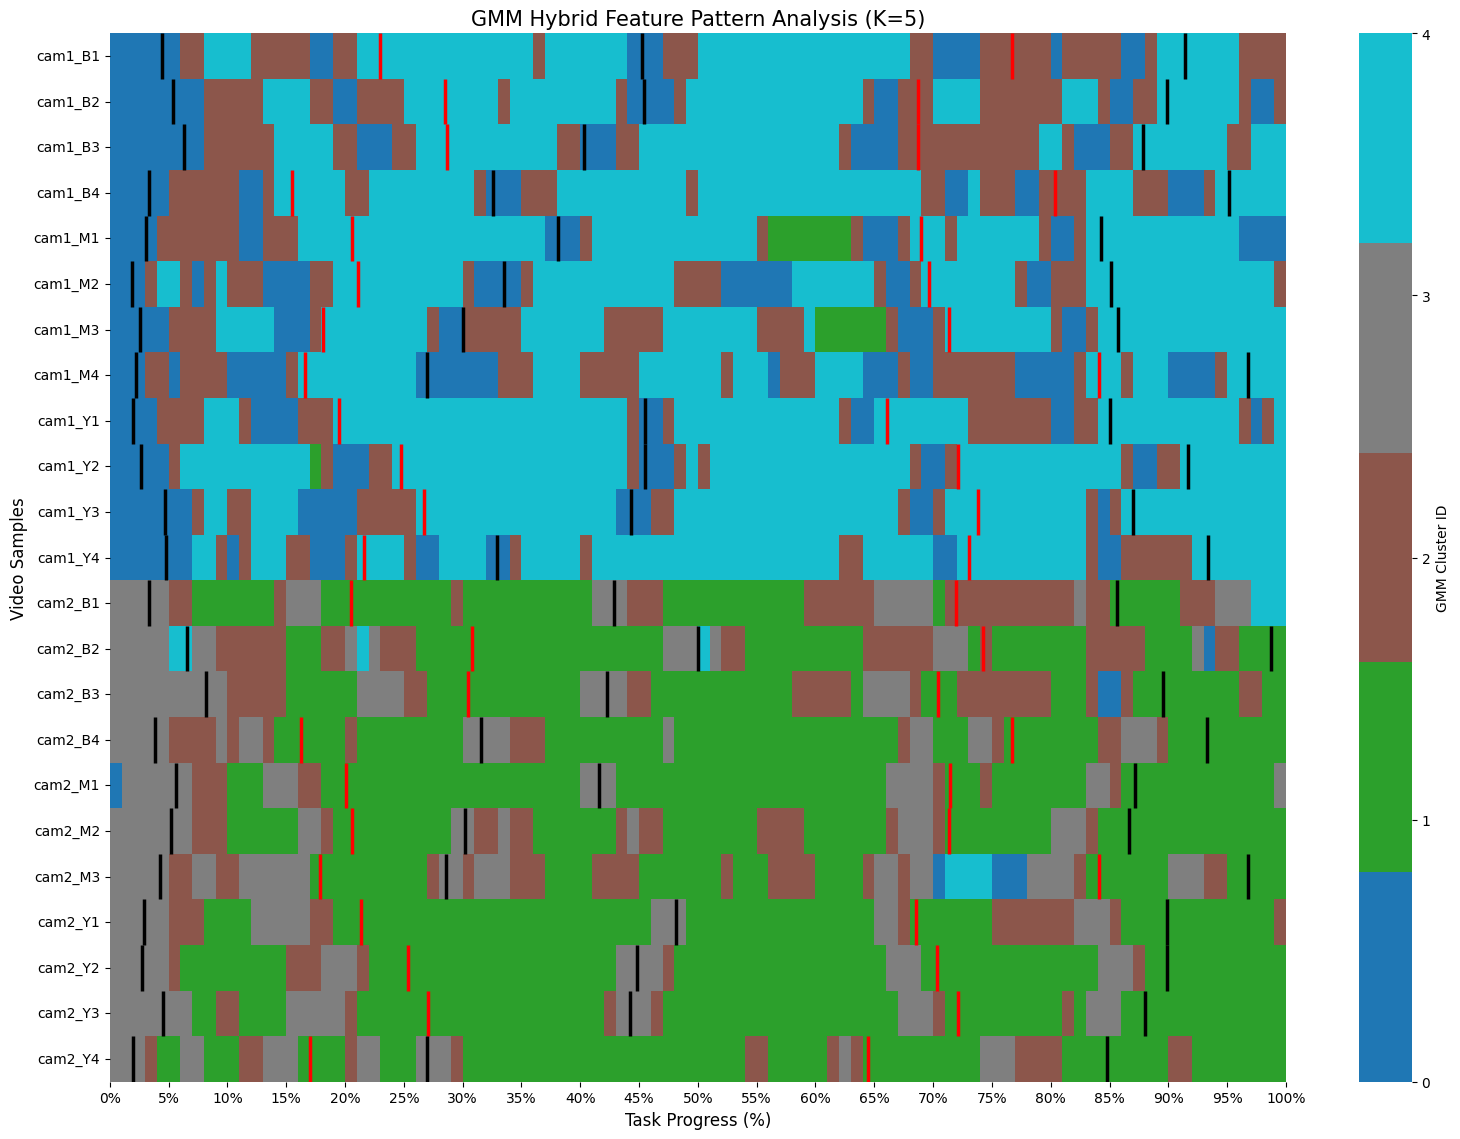


--- Analyzing Degree Features ---
Performing GMM clustering (K=5) on combined features...


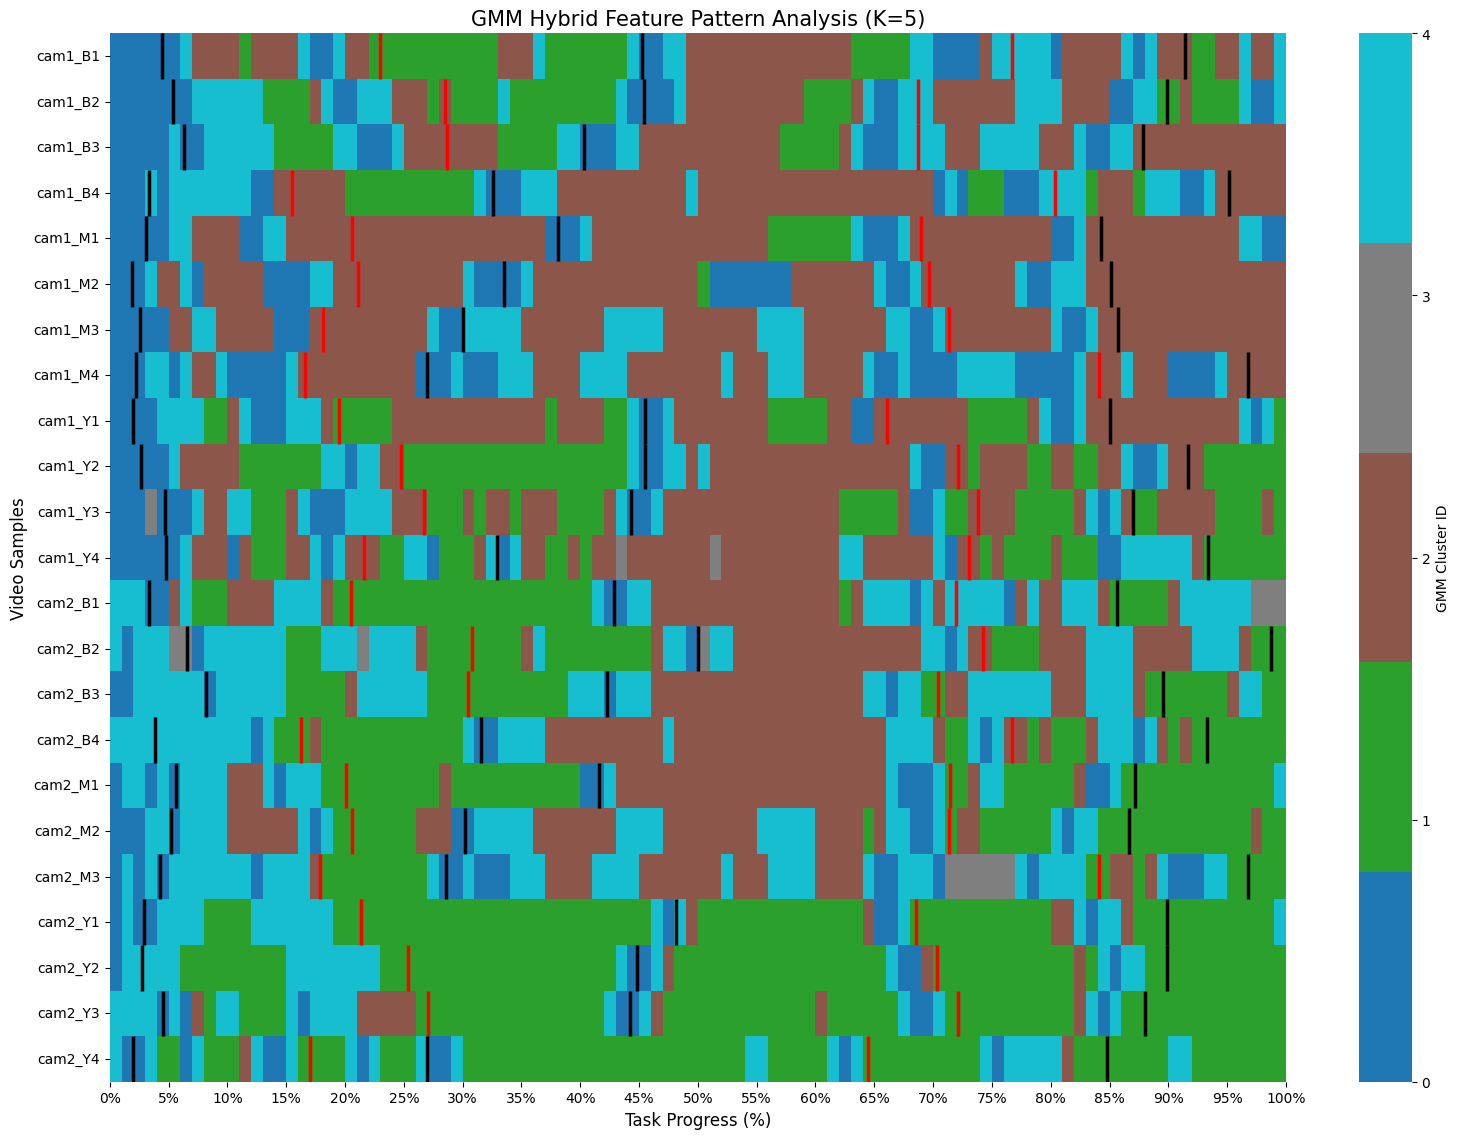


--- Analyzing Ratio Features ---
Performing GMM clustering (K=5) on combined features...


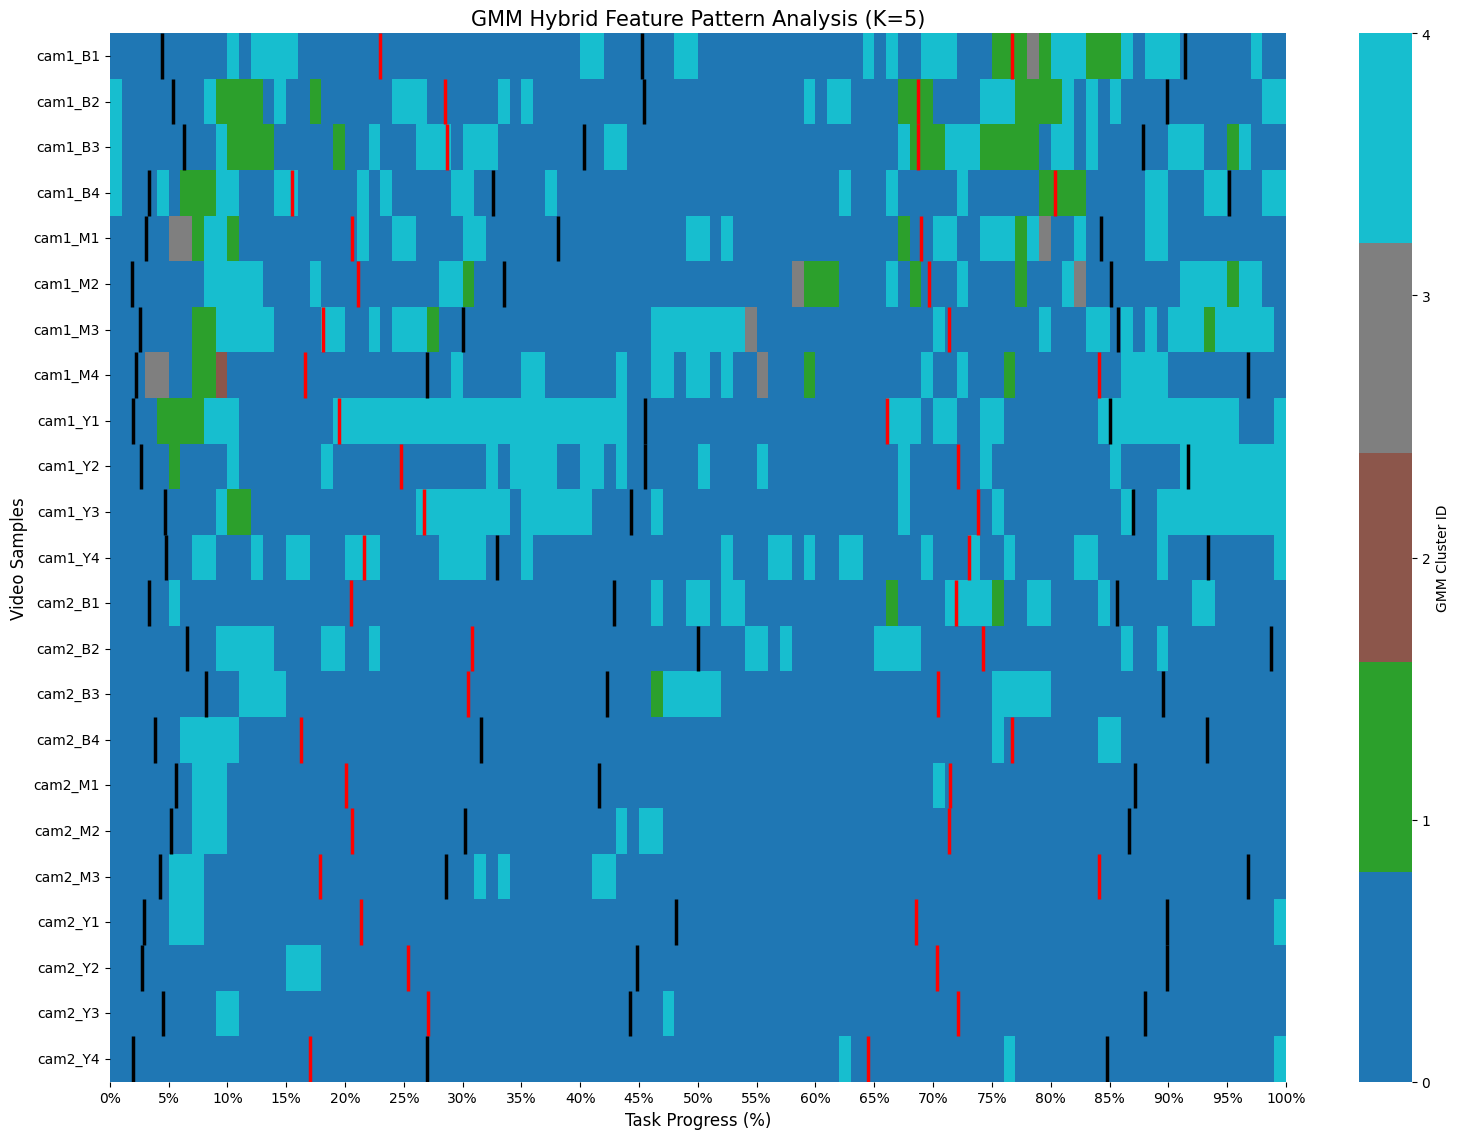


--- Analyzing Speed Features ---
Performing GMM clustering (K=5) on combined features...


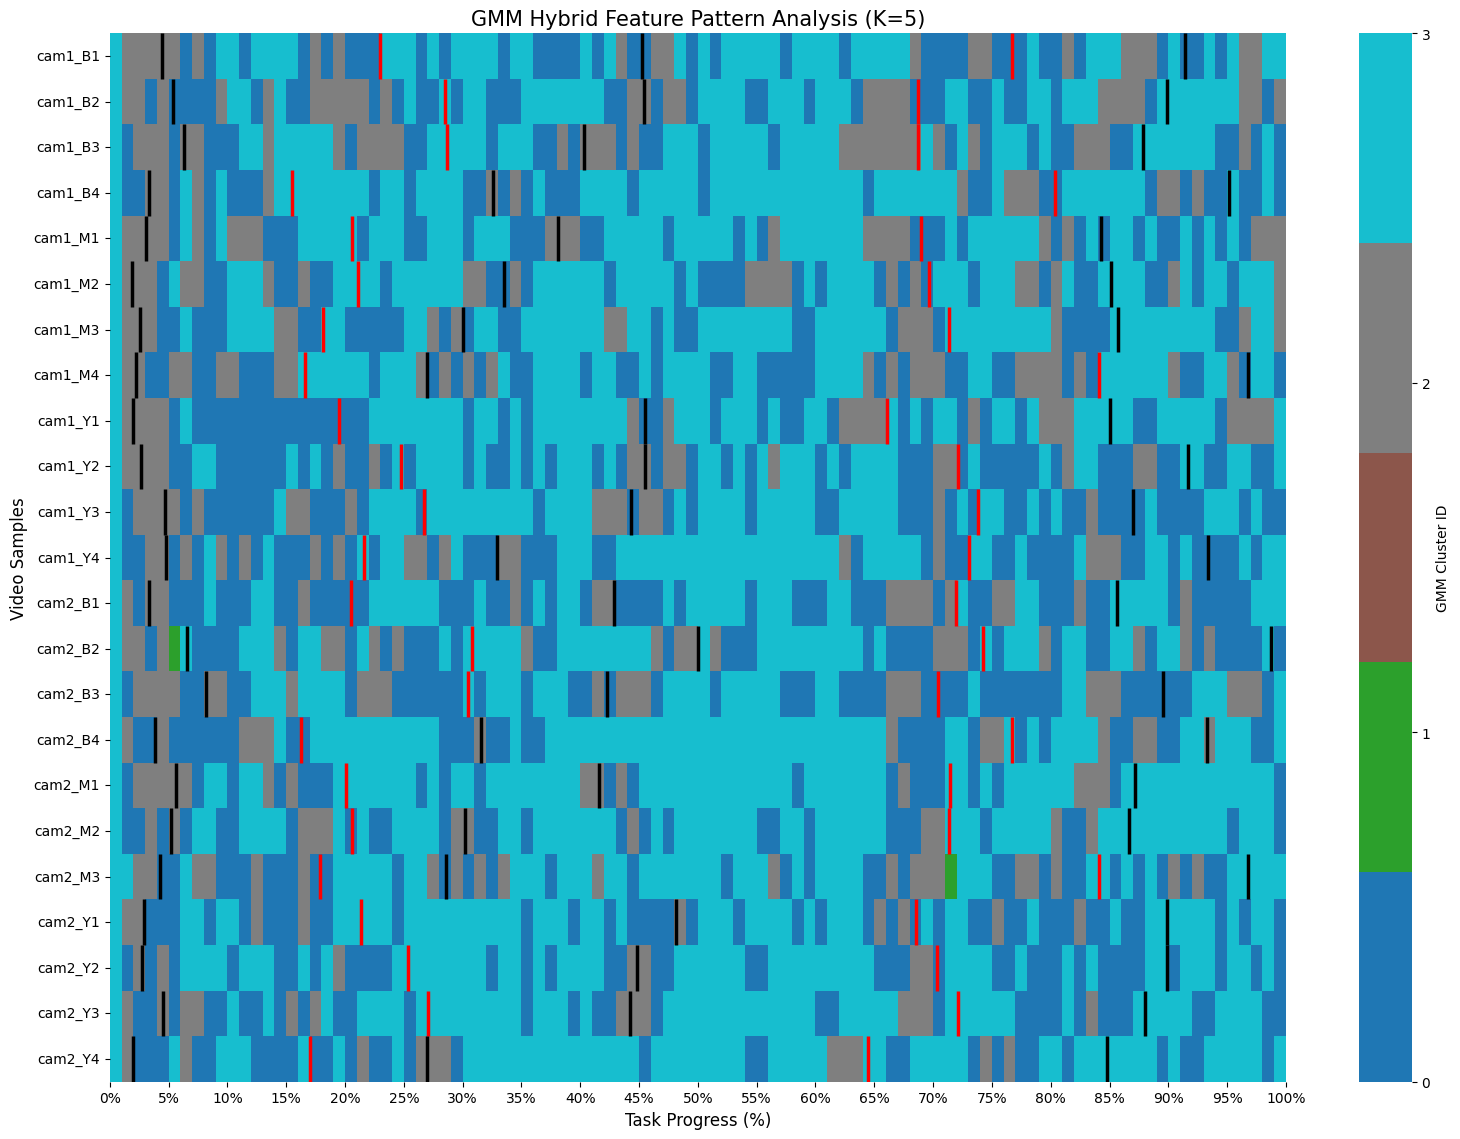


--- Analyzing Acceleration Features ---
Performing GMM clustering (K=5) on combined features...


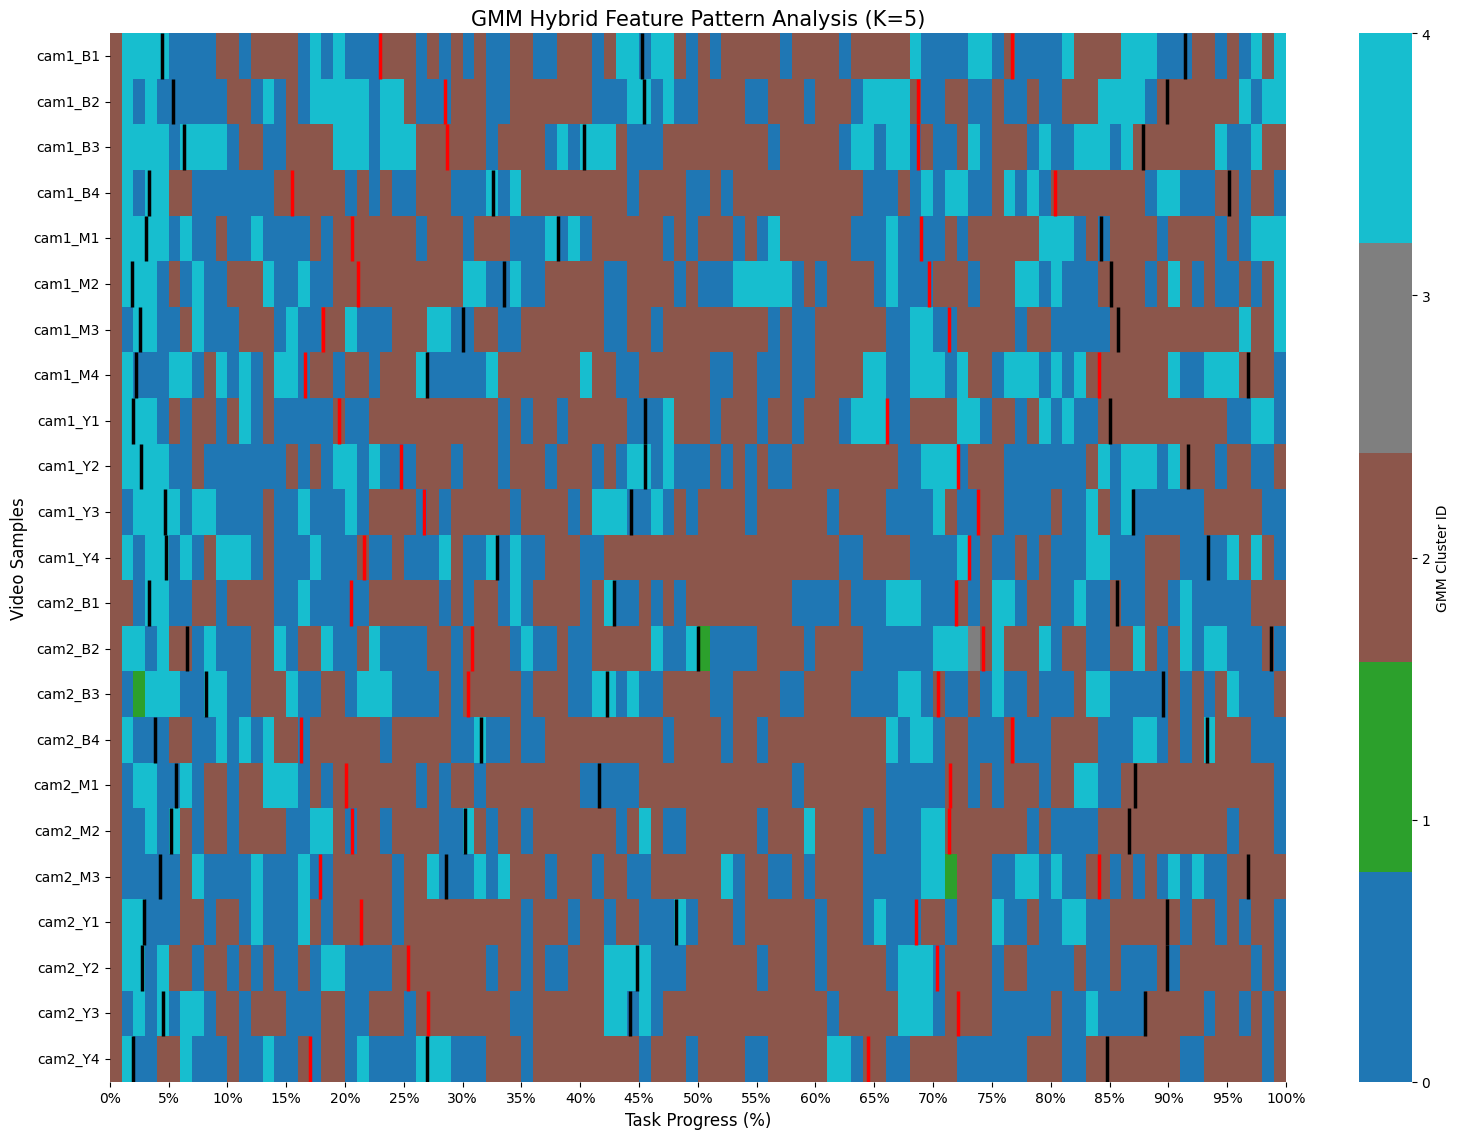

In [9]:
#xyn
print("\n--- Analyzing Reshaped XYN Features ---")
kmeans_xyn, parallel_matrix_xyn = plot_hybrid_feature_heatmap(X_scaled_xyn, npz_norm_path, json_label_path, n_clusters=cluster)
#degree only
print("\n--- Analyzing Degree Features ---")
kmeans_deg, parallel_matrix_deg = plot_hybrid_feature_heatmap(X_scaled_deg, npz_norm_path, json_label_path, n_clusters=cluster)
#ratio only
print("\n--- Analyzing Ratio Features ---")
kmeans_ratio, parallel_matrix_ratio = plot_hybrid_feature_heatmap(X_scaled_ratio, npz_norm_path, json_label_path, n_clusters=cluster)
#speed only
print("\n--- Analyzing Speed Features ---")
kmeans_speed, parallel_matrix_speed = plot_hybrid_feature_heatmap(X_scaled_speed, npz_norm_path, json_label_path, n_clusters=cluster)
#acc only
print("\n--- Analyzing Acceleration Features ---")
kmeans_accel, parallel_matrix_accel = plot_hybrid_feature_heatmap(X_scaled_accel, npz_norm_path, json_label_path, n_clusters=cluster)


# Hybrid Features

In [18]:
cluster = 7


--- Analyzing Combined Features (Deg+Ratio+Spd+Acc) ---
Performing GMM clustering (K=7) on combined features...


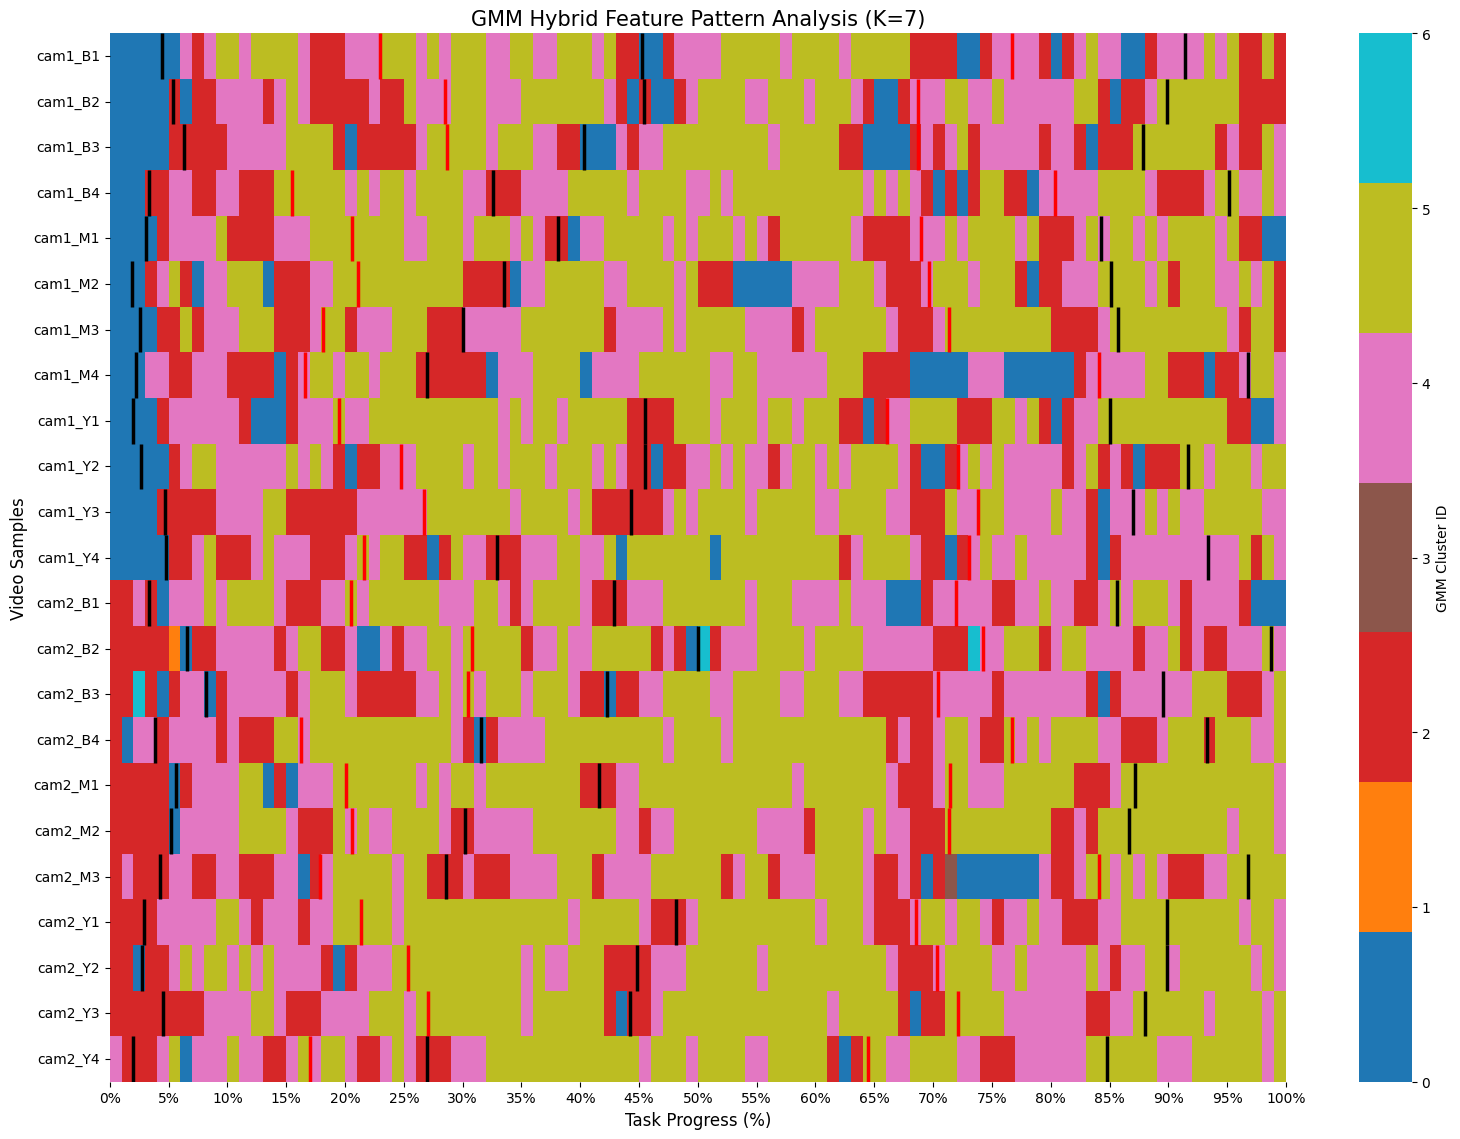


--- Analyzing Combined Features (Deg+Ratio+Spd) ---
Performing GMM clustering (K=7) on combined features...


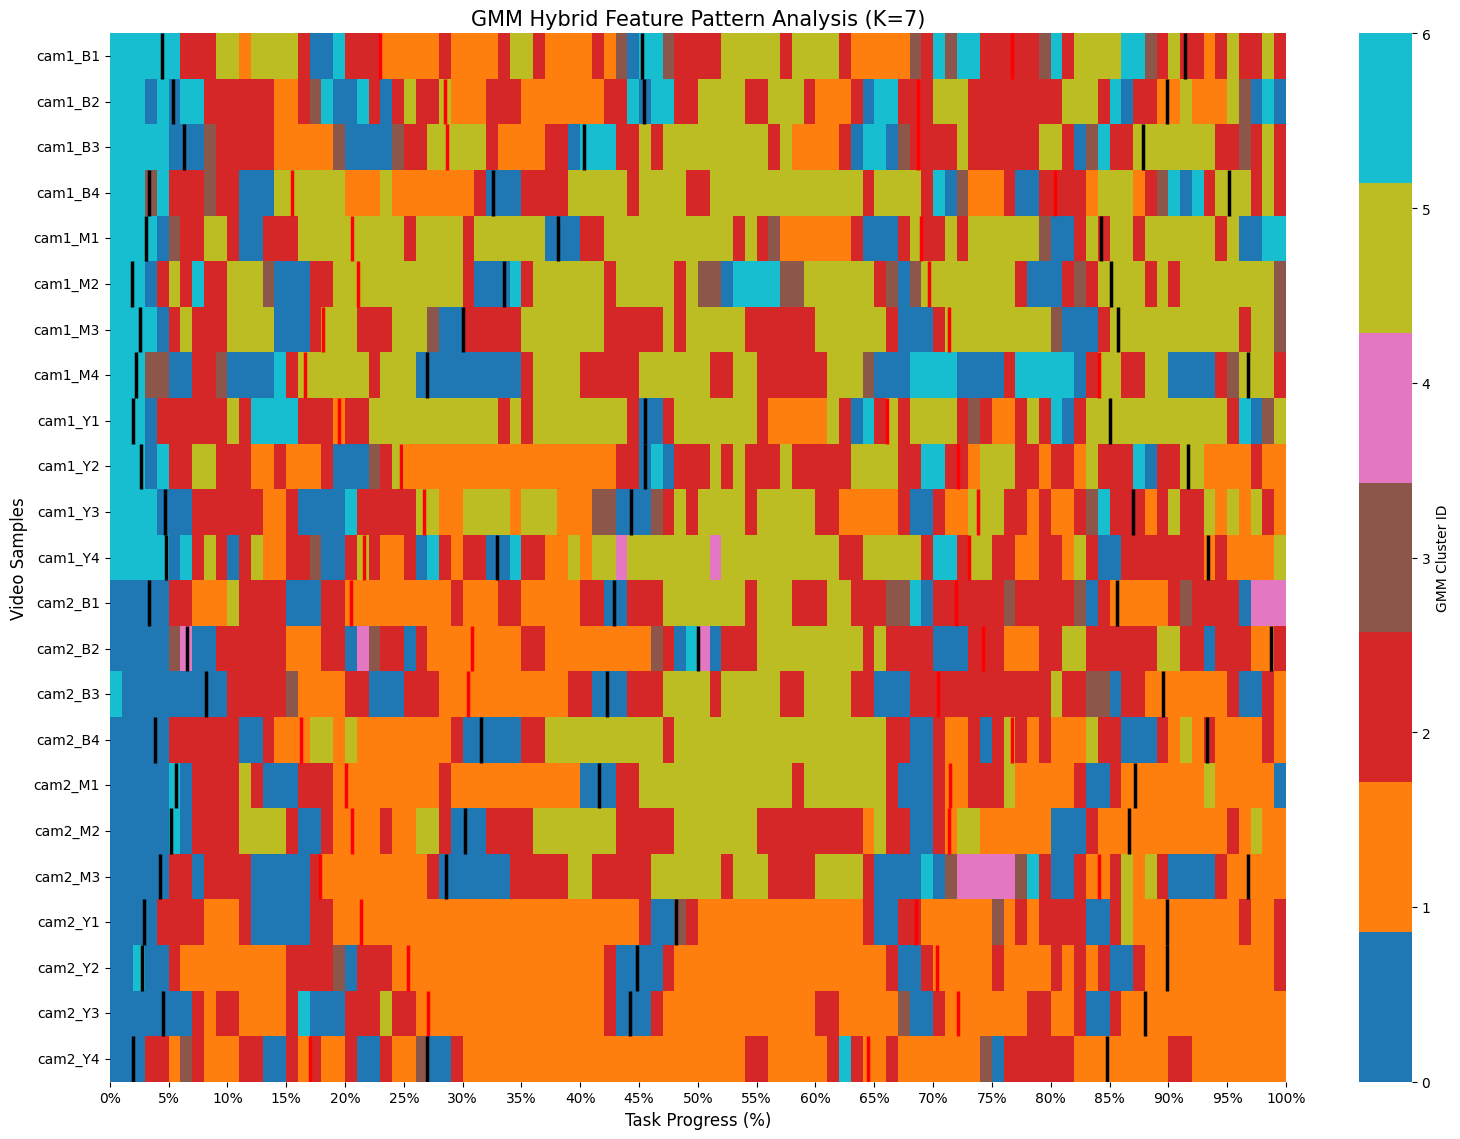


--- Analyzing Combined Features (Deg+Spd) ---
Performing GMM clustering (K=7) on combined features...


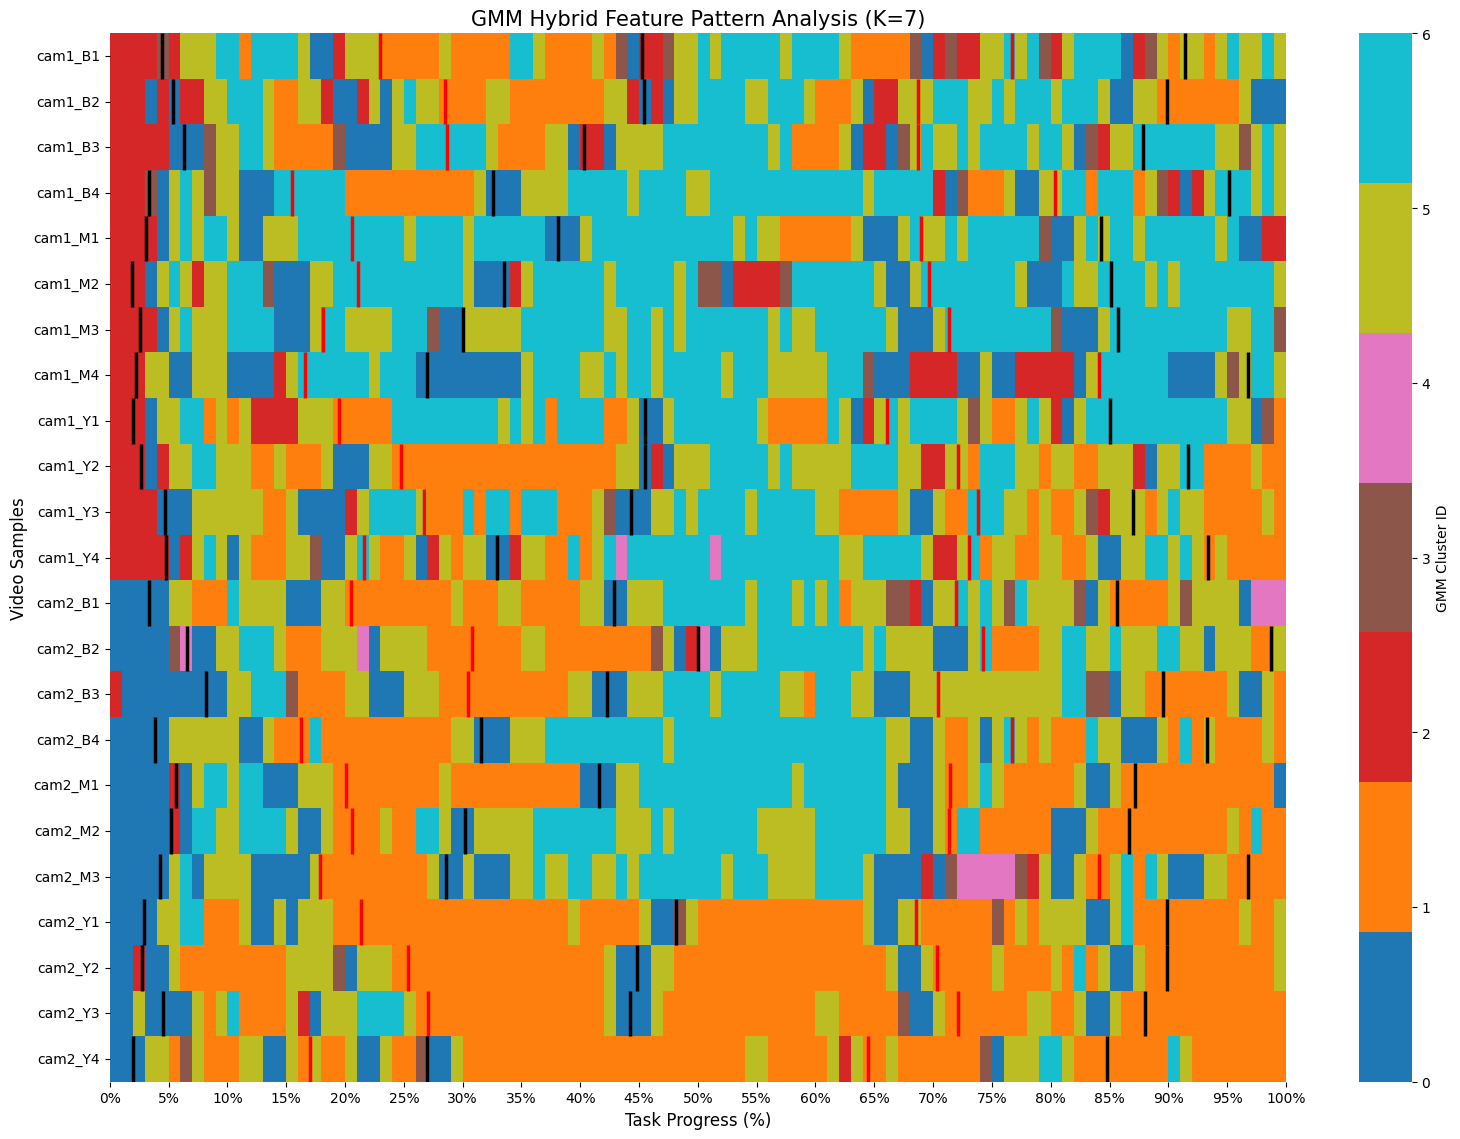


--- Analyzing Combined Features (Deg+Acc) ---
Performing GMM clustering (K=7) on combined features...


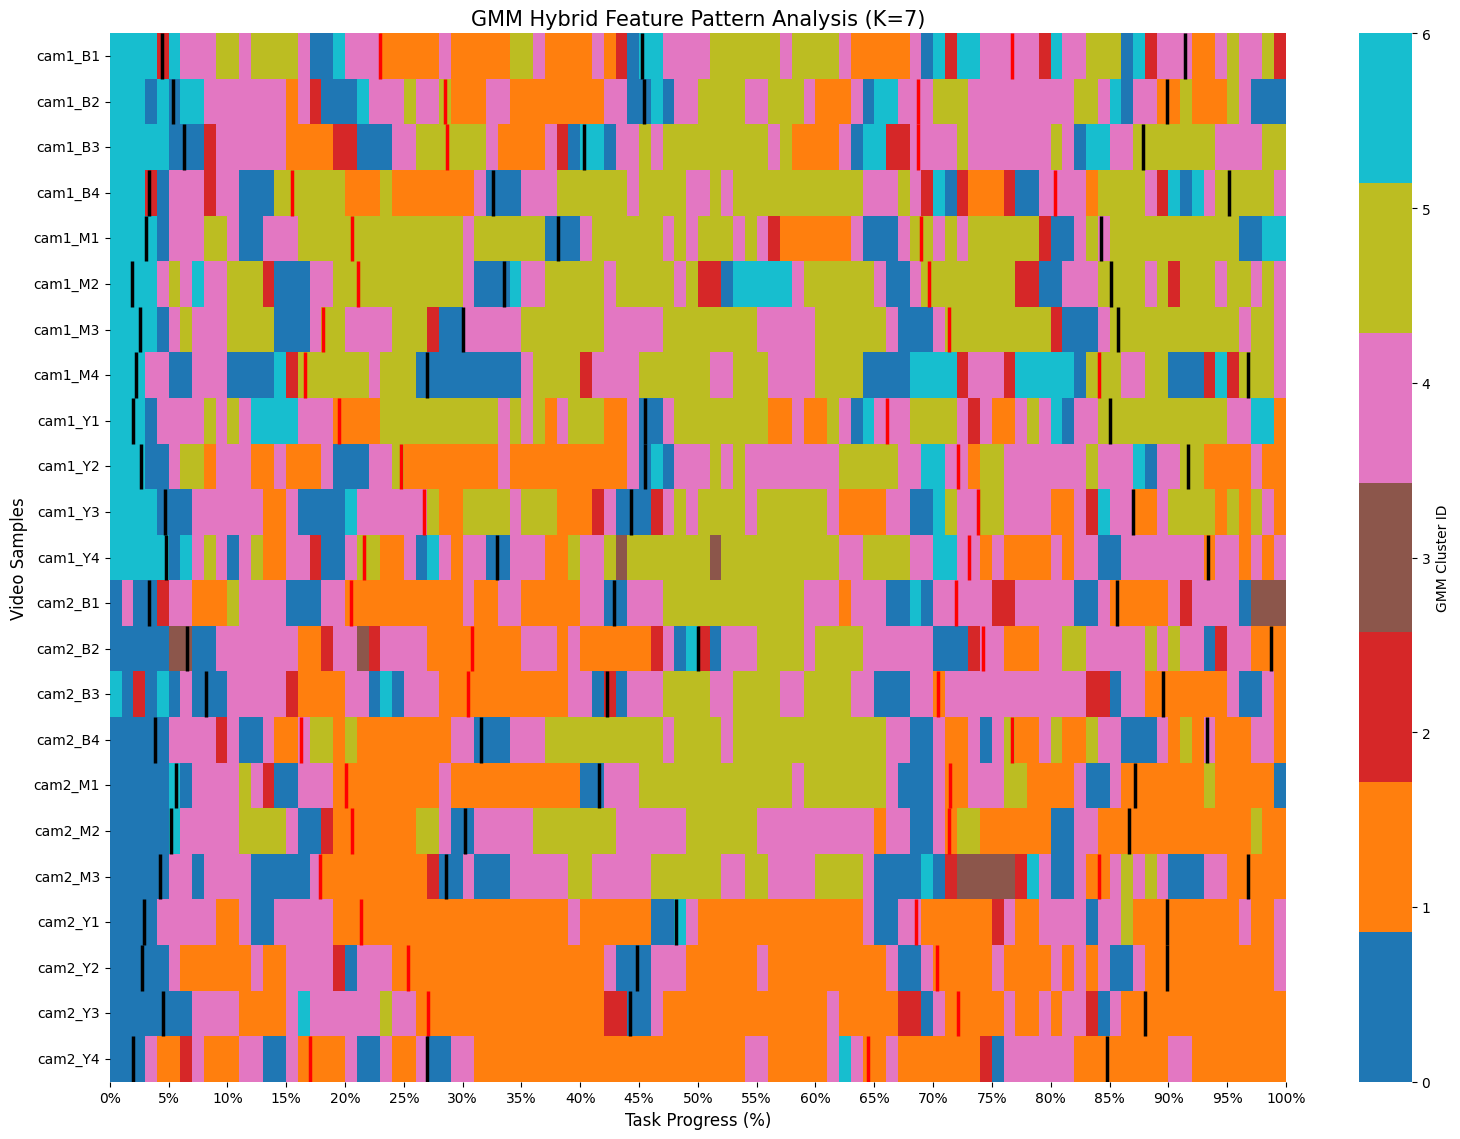

In [19]:
#features combined: degree + ratio + speed + accel
print("\n--- Analyzing Combined Features (Deg+Ratio+Spd+Acc) ---")
kmeans_all, parallel_matrix_all = plot_hybrid_feature_heatmap(X_scaled_all, npz_norm_path, json_label_path, n_clusters=cluster)

#deg ratio speed
print("\n--- Analyzing Combined Features (Deg+Ratio+Spd) ---")
kmeans_deg_ratio_speed, parallel_matrix_deg_ratio_speed = plot_hybrid_feature_heatmap(X_scaled_deg_ratio_speed, npz_norm_path, json_label_path, n_clusters=cluster)

#degree and speed
print("\n--- Analyzing Combined Features (Deg+Spd) ---")
kmeans_deg_speed, parallel_matrix_deg_speed = plot_hybrid_feature_heatmap(X_scaled_deg_speed, npz_norm_path, json_label_path, n_clusters=cluster)

#degree and accel
print("\n--- Analyzing Combined Features (Deg+Acc) ---")
kmeans_deg_accel, parallel_matrix_deg_accel = plot_hybrid_feature_heatmap(X_scaled_deg_accel, npz_norm_path, json_label_path, n_clusters=cluster)   

### CLUSTERING

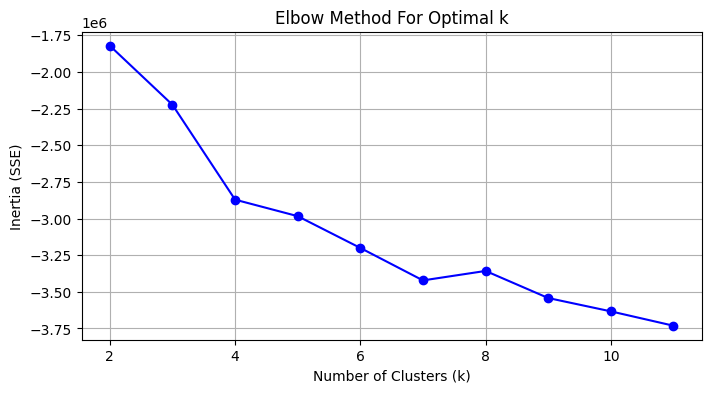

In [15]:
inertias = []
K_range = range(2, 12) #

X_stacked = X_scaled_deg_speed  # Change this to analyze different feature combinations
X_stacked = np.nan_to_num(X_stacked.astype(np.float64))

for k in K_range:
    # kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # kmeans.fit(X_scaled_deg_speed)
    # inertias.append(kmeans.inertia_)
    # GMMs
    gmm = GaussianMixture(
        n_components=k, 
        covariance_type='full', 
        random_state=42, 
        reg_covar=1e-6  # Added small value for numerical stability
    )
    
    # Fit the model and predict labels
    gmm.fit(X_stacked)
    inertias.append(gmm.bic(X_stacked))  # Using BIC for GMM instead of inertia

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [20]:

optimal_k = 7

gmm = GaussianMixture(
    n_components=optimal_k, 
    covariance_type='full', 
    random_state=42, 
    reg_covar=1e-6  # Added small value for numerical stability
)

# Fit the model and predict labels
labels = gmm.fit_predict(X_stacked)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 8107 13.3%
cluster 1: 16597 27.2%
cluster 2: 2773 4.5%
cluster 3: 1537 2.5%
cluster 4: 310 0.5%
cluster 5: 15750 25.8%
cluster 6: 16030 26.2%


## TSNE visulization

In [ ]:
# from sklearn.manifold import TSNE
# import pandas as pd

# sample_size = 3000 
# indices = np.linspace(0, len(X_scaled_deg_speed_accel) - 1, sample_size).astype(int)
# X_sample = X_scaled_deg_speed_accel[indices]
# labels_sample = labels[indices]

# tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
# X_tsne = tsne.fit_transform(X_sample)


# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
#                       c=labels_sample, 
#                       cmap='tab10', 
#                       alpha=0.6, 
#                       s=15)


# legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
# plt.gca().add_artist(legend1)

# plt.title(f"t-SNE Visualization of Action Clusters (K={optimal_k})", fontsize=15)
# plt.xlabel("t-SNE dimension 1")
# plt.ylabel("t-SNE dimension 2")
# plt.grid(True, alpha=0.3)
# plt.show()

In [27]:
optimal_k = 5

### Visulize Selected Postures of Each Cluster

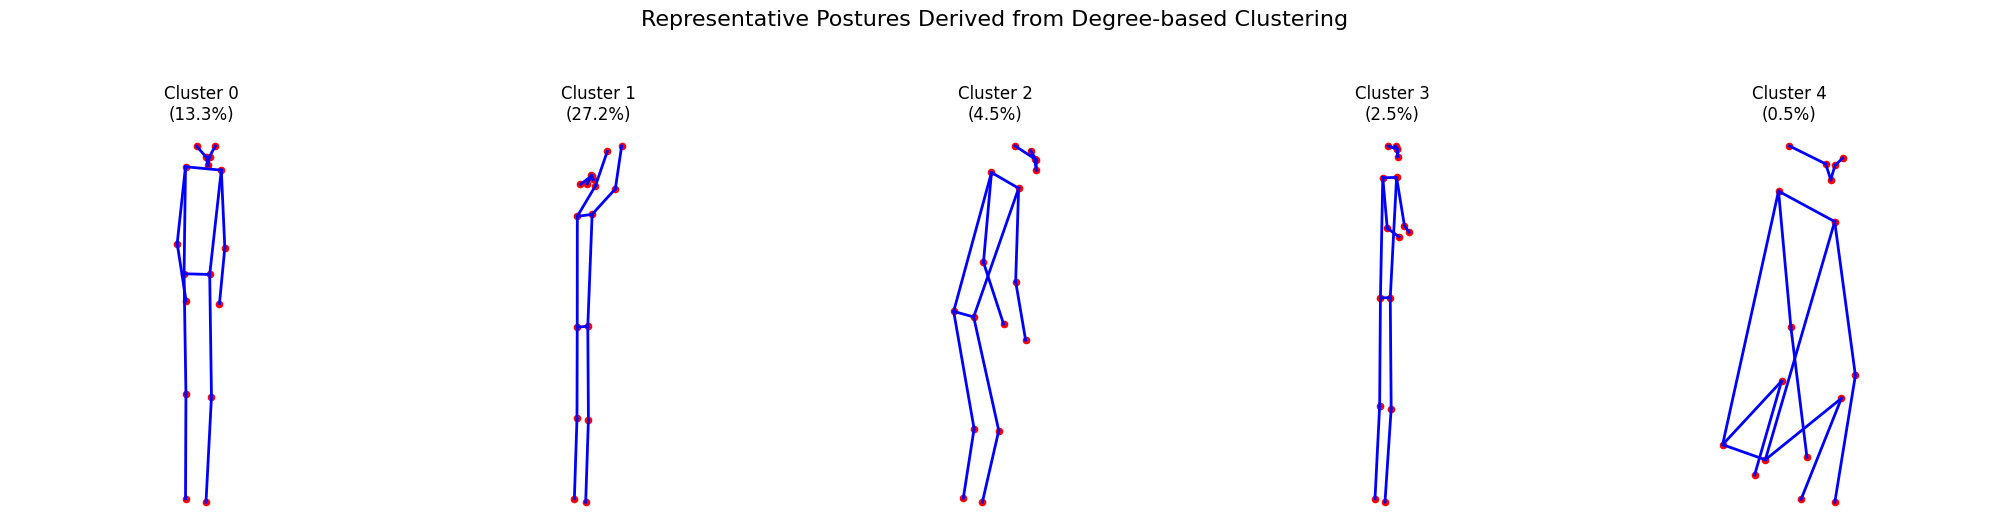

In [28]:
def plot_skeleton(points, title, ax):
    EDGES = [
        # Face
        (0, 1), (0, 2), (1, 3), (2, 4), 
        # Upper Body & Arms
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        # Torso
        (5, 11), (6, 12), (11, 12),
        # Lower Body & Legs
        (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    pts = points.reshape(17, 2)
    ax.scatter(pts[:, 0], -pts[:, 1], c='red', s=20) 
    for edge in EDGES:
        ax.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.axis('equal')
    ax.axis('off') 

# find representative postures for each cluster and plot them
plt.figure(figsize=(20, 5))

# X_scaled_deg.shape[1] = 9
# X_pos.shape[1] = 22 (skeleton points)
# Reshaped XYN Features:     (61104, 34)
X_pos = X_xyn.reshape(-1, 17, 2)

for i in range(optimal_k):
    cluster_indices = np.where(labels == i)[0]
    
    if len(cluster_indices) > 0:
        cluster_postures = X_pos[cluster_indices]

        representative_posture = np.mean(cluster_postures, axis=0)
        
        ax = plt.subplot(1, optimal_k, i+1)
        
        percentage = (len(cluster_indices) / len(labels)) * 100
        title_str = f"Cluster {i}\n({percentage:.1f}%)"
        
        plot_skeleton(representative_posture, title_str, ax)
    else:
        print(f"Warning: Cluster {i} has no samples.")

plt.suptitle("Representative Postures Derived from Degree-based Clustering", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Conclusions:

## 1. Feature selection and combination

## 2. Posture cluster and step segmentation